# 5) Random forest

- Type of model: SUPERVISED
- Model type of approach: ensemble of self-finding heuristics (bagging of decision trees)


In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GroupKFold

PROC_DIR = Path("./../artifacts")
FIG_DIR = Path("./../figures")
RESULTS_DIR = PROC_DIR / "results"
RESULTS_DIR.mkdir(exist_ok=True)

df = pd.read_csv(PROC_DIR / "features.csv")
sel = json.loads((PROC_DIR / "feature_selection.json").read_text())
y = (df["label"] == "bumpy").to_numpy().astype(int)      # 1 = bumpy, 0 = smooth

print(f"{len(df)} windows, {df['recording_id'].nunique()} recordings, {df['participant'].nunique()} participants")
print(f"{len(sel['kept'])} features kept by the filters, {len(sel['all'])} candidates")

CLASSES = ["bumpy", "smooth"]
CLASS_COLOR = {"bumpy": "orange", "smooth": "blue"}
PALETTE = ["blue", "orange", "green"]

plt.rcParams.update(
    {"axes.grid": True, "grid.color": "gray",
     "axes.spines.top": False, "axes.spines.right": False,
     "lines.linewidth": 1.0, "figure.dpi": 100})


768 windows, 26 recordings, 3 participants
52 features kept by the filters, 66 candidates


## 5.1 Hyperparams Random Forest

In [2]:
N_FOLDS = sel["n_folds"]
ALL = sel["all"]
N_TREES = 200
DEPTH = 3

# split iterators: lists of (train_mask, test_mask) over windows
SPLITS = {
    "grouped folds": [((df["fold"] != k).to_numpy(), (df["fold"] == k).to_numpy()) for k in range(N_FOLDS)],
    "leave-one-participant-out": [((df["participant"] != p).to_numpy(), (df["participant"] == p).to_numpy())
                                  for p in sorted(df["participant"].unique())],
}

## 5.2 Forest Feature selection

Same two features as for k-means and decision tree.  

Every tree still draws axis-aligned rectangles, but each tree sees a different bootstrap sample, so the thresholds differ slightly per tree.

The background shows the forest's **predicted probability of bumpy** (fraction of trees voting bumpy): The black line is the 0.5 decision boundary. 

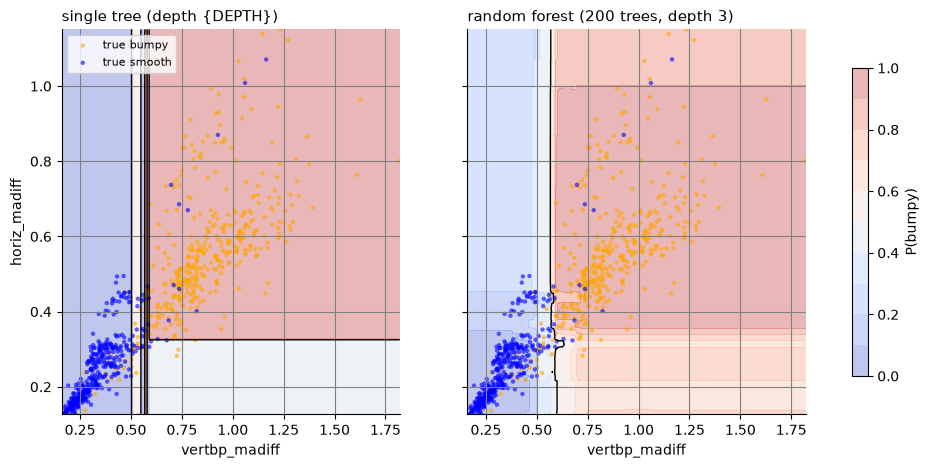

In [3]:
def forest(**params):
    return RandomForestClassifier(n_estimators=params.pop("n_estimators", N_TREES), random_state=0, n_jobs=-1, **params)

feats2 = ["vertbp_madiff", "horiz_madiff"]
tree2 = DecisionTreeClassifier(max_depth=DEPTH, random_state=0).fit(df[feats2], y)
rf2 = forest(max_depth=DEPTH).fit(df[feats2], y)

x0, x1 = df[feats2[0]].to_numpy(), df[feats2[1]].to_numpy()
g0, g1 = np.meshgrid(np.linspace(x0.min(), x0.max(), 300), np.linspace(x1.min(), x1.max(), 300))
G = pd.DataFrame(np.c_[g0.ravel(), g1.ravel()], columns=feats2)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
for ax, (name, model) in zip(axes, {"single tree (depth {DEPTH})": tree2, f"random forest ({N_TREES} trees, depth {DEPTH})": rf2}.items()):
    
    proba = model.predict_proba(G)[:, 1].reshape(g0.shape)
    cf = ax.contourf(g0, g1, proba, levels=np.linspace(0, 1, 11), cmap="coolwarm", alpha=0.35)
    ax.contour(g0, g1, proba, levels=[0.5], colors="black", linewidths=1)
    
    for lab in CLASSES:
        m = (df["label"] == lab).to_numpy()
        ax.scatter(x0[m], x1[m], s=10, alpha=0.6, color=CLASS_COLOR[lab], edgecolors="none", label=f"true {lab}")
        
    ax.set(xlabel=feats2[0])
    ax.set_title(name, loc="left", fontsize=11)

axes[0].set_ylabel(feats2[1]); axes[0].legend(fontsize=8)

fig.colorbar(cf, ax=axes, label="P(bumpy)", shrink=0.8)
fig.savefig(FIG_DIR / "rf_2d_regions.png", dpi=120, bbox_inches="tight"); plt.show()

## 5.3 Depth vs Accuracy Analysis: forest versus single tree

In [ ]:
DEPTHS = [1, 2, 3, 4, 5, 6, 8, 10, None]

def cv_accuracy(splits, feats, make):
    tr_acc, te_acc = [], []
    for tr, te in splits:
        clf = make().fit(df.loc[tr, feats], y[tr])
        tr_acc.append(clf.score(df.loc[tr, feats], y[tr]))
        te_acc.append(clf.score(df.loc[te, feats], y[te]))

    return np.mean(tr_acc), np.mean(te_acc), np.min(te_acc)

MAKERS = {"forest": lambda d: forest(max_depth=d),
          "single tree": lambda d: DecisionTreeClassifier(max_depth=d, random_state=0)}

rows = [{"split": s, "model": m, "depth": "full" if d is None else d,
         **dict(zip(["train", "test", "worst test"], cv_accuracy(SPLITS[s], ALL, lambda: make(d))))}
        for s in SPLITS for m, make in MAKERS.items() for d in DEPTHS]

depth_curve = pd.DataFrame(rows)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.8), sharey=True)
for ax, (s, d) in zip(axes, depth_curve.groupby("split", sort=False)):
    xs = range(len(DEPTHS))
    
    f, t = d[d["model"] == "forest"], d[d["model"] == "single tree"]
    ax.plot(xs, f["train"], marker="o", markersize=4, color=PALETTE[0], label="forest train")
    ax.plot(xs, f["test"], marker="o", markersize=4, color=PALETTE[1], label="forest test (mean)")
    ax.plot(xs, f["worst test"], marker="o", markersize=4, color=PALETTE[1], linestyle="--", alpha=0.6, label="forest test (worst split)")
    ax.plot(xs, t["test"], marker="o", markersize=4, color="gray", alpha=0.8, label="single tree test (mean)")
    ax.set_xticks(xs, f["depth"]); ax.set(xlabel="max_depth")
    ax.set_title(s, loc="left", fontsize=10)

axes[0].set_ylabel("accuracy"); axes[0].legend(fontsize=8)
fig.tight_layout(); fig.savefig(FIG_DIR / "rf_depth_curve.png", dpi=120, bbox_inches="tight"); plt.show()

depth_curve.pivot_table(index="depth", columns=["split", "model"], values="test", sort=False).round(3)

## 5.3 Number of trees and out-of-bag error

More trees never make a random forest overfit more, the vote only gets more stable. The question is how many are needed before the accuracy stops changing.

Each tree leaves out about a third of the windows from its bootstrap sample. Predicting those **out-of-bag (OOB)** windows gives a free internal validation score. But the windows of one recording are strongly correlated, so a window's neighbours are almost always in the bag: the OOB score is **optimistic** compared with testing on an unseen participant.

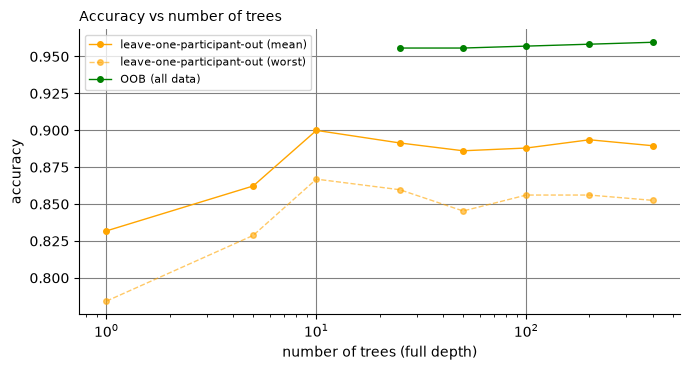

,leave-one-participant-out (mean),leave-one-participant-out (worst),OOB (all data)
n_trees,,,
1,0.832,0.784,NaN
5,0.862,0.829,NaN
10,0.900,0.867,NaN
25,0.891,0.860,0.956
50,0.886,0.845,0.956
100,0.888,0.856,0.957
200,0.894,0.856,0.958
400,0.890,0.853,0.960


In [5]:
N_GRID = [1, 5, 10, 25, 50, 100, 200, 400]

rows = []
for n in N_GRID:
    lopo = [forest(n_estimators=n).fit(df.loc[tr, ALL], y[tr]).score(df.loc[te, ALL], y[te])
            for tr, te in SPLITS["leave-one-participant-out"]]
    oob = forest(n_estimators=n, oob_score=True, bootstrap=True).fit(df[ALL], y).oob_score_ if n >= 25 else np.nan
    rows.append({"n_trees": n, "leave-one-participant-out (mean)": np.mean(lopo),
                 "leave-one-participant-out (worst)": np.min(lopo), "OOB (all data)": oob})
ntree_curve = pd.DataFrame(rows).set_index("n_trees")

fig, ax = plt.subplots(figsize=(7, 3.8))
ax.plot(ntree_curve.index, ntree_curve.iloc[:, 0], marker="o", markersize=4, color=PALETTE[1], label=ntree_curve.columns[0])
ax.plot(ntree_curve.index, ntree_curve.iloc[:, 1], marker="o", markersize=4, color=PALETTE[1], linestyle="--", alpha=0.6, label=ntree_curve.columns[1])
ax.plot(ntree_curve.index, ntree_curve.iloc[:, 2], marker="o", markersize=4, color=PALETTE[2], label=ntree_curve.columns[2])
ax.set_xscale("log"); ax.set(xlabel="number of trees (full depth)", ylabel="accuracy")
ax.set_title("Accuracy vs number of trees", loc="left", fontsize=10); ax.legend(fontsize=8)

fig.tight_layout(); fig.savefig(FIG_DIR / "rf_ntrees_curve.png", dpi=120, bbox_inches="tight"); plt.show()

ntree_curve.round(3)

## 5.4 Random forest feature break-down

The single tree used only a handful of features, and which one it picked changed per fold. The forest spreads the importance over all features that carry information, because at each split only a random subset (`max_features="sqrt"`, 8 of 66) is available.

Impurity-based importance, averaged over the trees and shown stacked per grouped fold. Top 20 features.

In [ ]:
TOP = 20

imp = pd.DataFrame({f"fold {k}": forest().fit(df.loc[tr, ALL], y[tr]).feature_importances_
                    for k, (tr, _) in enumerate(SPLITS["grouped folds"])}, index=ALL)

imp["mean"] = imp.mean(axis=1)
imp["Fisher rank"] = [sel["ranked_by_fisher"].index(f) + 1 if f in sel["ranked_by_fisher"] else "removed by filter" for f in imp.index]
imp = imp.sort_values("mean", ascending=False).head(TOP)

fig, ax = plt.subplots(figsize=(7, 0.35 * len(imp) + 1))
fold_cols = [c for c in imp.columns if c.startswith("fold")]
left = np.zeros(len(imp))

for c, color in zip(fold_cols, ["blue", "orange", "green", "gray"]):
    ax.barh(range(len(imp))[::-1], imp[c] / len(fold_cols), left=left, color=color, height=0.6, label=c)
    left += imp[c].to_numpy() / len(fold_cols)

ax.set_yticks(range(len(imp))[::-1], imp.index, fontsize=8)
ax.set_xlabel("mean importance (stacked contribution per fold)")
ax.set_title(f"Random forest feature importance (top {TOP} of {len(ALL)} features)", loc="left", fontsize=10)
ax.grid(axis="y", visible=False); ax.legend(fontsize=8)

fig.tight_layout(); fig.savefig(FIG_DIR / "rf_importance.png", dpi=120, bbox_inches="tight"); plt.show()

imp.round(3)

## 5.5 Cross-validation

Nested CV, same as for the decision tree:

- **outer loop**: leave one participant out, this participant is only used for the final score
- **inner loop**: on the remaining two participants, a grouped CV (by recording) picks `max_depth` and `max_features`
- the forest is then refitted on all outer-training data with the chosen hyperparameters

Compared against:
- a **default forest** (full depth, `max_features="sqrt"`), no tuning
- the **full-depth single tree** and the **stump** from notebook 4
- **Threshold on `vertbp_madiff`** as a sanity check

In [ ]:
INNER_GRID = [{"max_depth": d, "max_features": f} for d in [2, 3, 5, 8, None] for f in ["sqrt", 0.3]]

def inner_splits(tr):
    idx = np.flatnonzero(tr)
    inner = GroupKFold(n_splits=4).split(idx, groups=df.loc[tr, "recording_id"])
    return [(np.isin(np.arange(len(df)), idx[a]), np.isin(np.arange(len(df)), idx[b])) for a, b in inner]

def nested_forest(tr, te, feats):
    inner = inner_splits(tr)
    best = max(INNER_GRID, key=lambda p: cv_accuracy(inner, feats, lambda: forest(**p))[1])
    clf = forest(**best).fit(df.loc[tr, feats], y[tr])
    return clf.predict(df.loc[te, feats]), best

def default_forest(tr, te, feats):
    return forest().fit(df.loc[tr, feats], y[tr]).predict(df.loc[te, feats])

def stump(tr, te, feats):
    return DecisionTreeClassifier(max_depth=1, random_state=0).fit(df.loc[tr, feats], y[tr]).predict(df.loc[te, feats])

def full_tree(tr, te, feats):
    return DecisionTreeClassifier(random_state=0).fit(df.loc[tr, feats], y[tr]).predict(df.loc[te, feats])

def threshold_baseline(tr, te, f="vertbp_madiff"):
    x = df[f].to_numpy()
    thr = (np.median(x[tr][y[tr] == 1]) + np.median(x[tr][y[tr] == 0])) / 2
    return (x[te] > thr).astype(int)

# nested CV is the slow part: cache its out-of-fold predictions for 5.6 and 5.7
nested_pred = {s: {} for s in SPLITS}

rows, chosen = [], {}
for p, (tr, te) in zip(sorted(df["participant"].unique()), SPLITS["leave-one-participant-out"]):
    pred, best = nested_forest(tr, te, ALL)
    nested_pred["leave-one-participant-out"][p] = pred
    chosen[p] = best
    
    for model, yhat in {"forest, tuned by inner CV": pred, "default forest": default_forest(tr, te, ALL),
                        "full-depth tree": full_tree(tr, te, ALL), "stump (depth 1)": stump(tr, te, ALL),
                        "baseline: threshold on vertbp_madiff": threshold_baseline(tr, te)}.items():
        rows.append({"model": model, "held-out participant": p, "accuracy": (yhat == y[te]).mean()})

nested = pd.DataFrame(rows).pivot(index="model", columns="held-out participant", values="accuracy")
nested["mean"] = nested.mean(axis=1)

print("hyperparameters chosen by the inner CV per held-out participant:")

for p, b in chosen.items():
    print(f"  {p}: {b}")
    
nested.sort_values("mean", ascending=False).round(3)

**Takeaway**

- Averaging fixes the overfitting of the single tree: the full-depth forest scores 0.89 on an unseen participant, compared with 0.78 for the full-depth tree, and its accuracy stays flat as depth grows (5.2).
- It still does not beat the stump or the threshold on `vertbp_madiff`. The bumpy/smooth split is essentially one-dimensional, so the extra features mostly add participant-specific variation that does not transfer.
- Tuning in the inner CV does not help (0.886 vs 0.894 for the default forest). With only two training participants, the inner folds are too noisy to pick hyperparameters reliably.
- The OOB score (~0.96) is clearly optimistic compared with leave-one-participant-out (~0.89), because windows from the same recording are correlated.

## 5.6 Macro Evaluation: Per recording

For every recording, the fraction of its windows predicted *bumpy* by the nested-CV forest when that recording's participant was held out.

In [ ]:
pred = np.zeros(len(df), dtype=int)

for p, (tr, te) in zip(sorted(df["participant"].unique()), SPLITS["leave-one-participant-out"]):
    pred[te] = nested_pred["leave-one-participant-out"][p]

per_rec = (df.assign(pred_bumpy=pred).groupby("recording_id")
             .agg(label=("label", "first"), frac_bumpy=("pred_bumpy", "mean"), n_windows=("pred_bumpy", "size"))
             .sort_values(["label", "frac_bumpy"]))

fig, ax = plt.subplots(figsize=(9, 3.8))

ax.bar(range(len(per_rec)), per_rec["frac_bumpy"], color=per_rec["label"].map(CLASS_COLOR), width=0.7)
ax.axhline(0.5, color="black", linewidth=0.8, linestyle="--")
ax.set_xticks(range(len(per_rec)), per_rec.index, rotation=90, fontsize=8)
ax.set(ylabel="fraction of windows predicted bumpy", ylim=(0, 1.02))
ax.set_title("Random forest (nested CV, leave-one-participant-out): per recording, bar colour = true label", loc="left", fontsize=10)
ax.grid(axis="x", visible=False)

fig.tight_layout(); fig.savefig(FIG_DIR / "rf_per_recording.png", dpi=120, bbox_inches="tight"); plt.show()

rec_acc = ((per_rec["frac_bumpy"] > 0.5) == (per_rec["label"] == "bumpy")).mean()
print(f"majority vote per recording: {rec_acc:.0%} of {len(per_rec)} recordings correct")

## 5.7 Export results

Same format as the k-means and decision tree exports, so the files can be concatenated into one comparison table. Saved to `artifacts/results/`:

- `rf_metrics_per_fold.csv`: one row per split, model and held-out fold / participant, with confusion counts
- `rf_metrics_summary.csv`: mean and worst fold per split and model
- `rf_predictions.csv`: out-of-fold prediction for every window

- **precision**: of the windows predicted bumpy, the fraction that really are bumpy
- **recall**: of the bumpy windows, the fraction found
- **specificity**: of the smooth windows, the fraction correctly called smooth
- **balanced accuracy**: mean of recall and specificity, not affected by class imbalance within a fold

In [ ]:
from sklearn.metrics import confusion_matrix

def classification_metrics(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    safe = lambda a, b: a / b if b else np.nan
    precision, recall, specificity = safe(tp, tp + fp), safe(tp, tp + fn), safe(tn, tn + fp)

    return {"n": len(y_true), "tp": tp, "fp": fp, "tn": tn, "fn": fn,
            "accuracy": (tp + tn) / len(y_true), "balanced_accuracy": (recall + specificity) / 2,
            "precision": precision, "recall": recall, "specificity": specificity,
            "f1": safe(2 * precision * recall, precision + recall)}

FOLD_NAMES = {"grouped folds": [f"fold {k}" for k in range(N_FOLDS)],
              "leave-one-participant-out": sorted(df["participant"].unique())}

def cached_nested(split_name, fold_name, tr, te):
    if fold_name not in nested_pred[split_name]:
        nested_pred[split_name][fold_name] = nested_forest(tr, te, ALL)[0]
    return nested_pred[split_name][fold_name]

MODELS = {
    "forest, tuned by inner CV": cached_nested,
    "default forest": lambda s, f, tr, te: default_forest(tr, te, ALL),
    "full-depth tree": lambda s, f, tr, te: full_tree(tr, te, ALL),
    "stump (depth 1)": lambda s, f, tr, te: stump(tr, te, ALL),
    "baseline: threshold on vertbp_madiff": lambda s, f, tr, te: threshold_baseline(tr, te),
}

metric_rows, pred_frames = [], []
for split_name, splits in SPLITS.items():
    for model_name, predict in MODELS.items():
        for fold_name, (tr, te) in zip(FOLD_NAMES[split_name], splits):
            yhat = predict(split_name, fold_name, tr, te)
            metric_rows.append({"split": split_name, "model": model_name, "held_out": fold_name,
                                **classification_metrics(y[te], yhat)})
            pred_frames.append(df.loc[te, ["recording_id", "participant", "label"]]
                               .assign(split=split_name, model=model_name, held_out=fold_name,
                                       pred=np.where(yhat == 1, "bumpy", "smooth")))

per_fold = pd.DataFrame(metric_rows)
METRICS = ["accuracy", "balanced_accuracy", "precision", "recall", "specificity", "f1"]
summary = per_fold.groupby(["split", "model"])[METRICS].agg(["mean", "min"])
summary.columns = [f"{m}_{stat}" for m, stat in summary.columns]

per_fold.to_csv(RESULTS_DIR / "rf_metrics_per_fold.csv", index=False)
summary.to_csv(RESULTS_DIR / "rf_metrics_summary.csv")
pd.concat(pred_frames).rename_axis("window").to_csv(RESULTS_DIR / "rf_predictions.csv")
print(f"saved to {RESULTS_DIR.resolve()}")

summary[[f"{m}_mean" for m in METRICS]].round(3)